<a href="https://colab.research.google.com/github/sv9-ru/model-for-predict/blob/main/fit_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!wget "https://cmfdata.susu.ru/uploads_anal/5~1581073654-analysis/Analysis%20for%20Dataset%201.zip"

!unzip -j "Analysis for Dataset 1.zip"

--2026-04-04 08:04:13--  https://cmfdata.susu.ru/uploads_anal/5~1581073654-analysis/Analysis%20for%20Dataset%201.zip
Resolving cmfdata.susu.ru (cmfdata.susu.ru)... 37.75.250.13
Connecting to cmfdata.susu.ru (cmfdata.susu.ru)|37.75.250.13|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 139279 (136K) [application/zip]
Saving to: ‘Analysis for Dataset 1.zip’

Analysis for Datase 100%[===================>] 136.01K   265KB/s    in 0.5s    

2026-04-04 08:04:15 (265 KB/s) - ‘Analysis for Dataset 1.zip’ saved [139279/139279]

Archive:  Analysis for Dataset 1.zip
  inflating: example.py              
  inflating: dataset1_full.xlsx      
  inflating: dataset2.xlsx           
  inflating: dataset3.xlsx           
  inflating: dataset4.xlsx           


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from typing import Dict, Optional, Tuple, List, Any, Union

# ========== Подготовка данных и обучение модели (ваш исходный код) ==========
import numpy as np
import pandas as pd
from sklearn import preprocessing, metrics, svm
from sklearn.utils import shuffle

In [3]:
dataset1 = pd.read_excel('/content/dataset1_full.xlsx')
dataset4 = pd.read_excel('/content/dataset4.xlsx')

In [4]:
# Column numbers
MFR_obs = 5
DD = 7
MFR_err = 8
DD_err = 10

# Start row number
row_start = 3

# общие функции

In [5]:
# @title
import numpy as np
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error

def calculate_overfitting_ratio(model, X_train, y_train_ds1, X_test, y_test, y_scaler_ds1=None):
    """
    Вычисляет коэффициент переобучения как отношение ошибки на тесте к ошибке на трейне.
    Используется MAE.

    Parameters
    ----------
    model : обученная модель
    X_train, y_train_ds1 : обучающие данные (исходные или масштабированные, но без обратного масштабирования)
    X_test, y_test : тестовые данные (исходные или масштабированные, но без обратного масштабирования)
    y_scaler_ds1 : скалер для обратного преобразования предсказаний (если модель обучена на масштабированных y)

    Returns
    -------
    float : коэффициент переобучения (test_mae / train_mae)
    """
    # Предсказания на трейне
    y_train_ds1_pred = model.predict(X_train)
    if y_scaler_ds1 is not None:
        y_train_ds1_pred = y_scaler_ds1.inverse_transform(y_train_ds1_pred.reshape(-1, 1)).ravel()
        # y_train_ds1 тоже нужно привести к исходному масштабу, если он был масштабирован
        # но обычно y_train_ds1 уже в исходном масштабе, а предсказания мы обратно преобразовали
        # Если y_train_ds1 масштабирован, то его нужно предварительно обратно преобразовать
        # Для простоты считаем, что y_train_ds1 и y_test передаются в исходном масштабе
    train_mae = mean_absolute_error(y_train_ds1, y_train_ds1_pred)

    # Предсказания на тесте
    y_test_pred = model.predict(X_test)
    if y_scaler_ds1 is not None:
        y_test_pred = y_scaler_ds1.inverse_transform(y_test_pred.reshape(-1, 1)).ravel()
    test_mae = mean_absolute_error(y_test, y_test_pred)

    overfit_ratio = test_mae / train_mae
    return overfit_ratio


def calculate_cv_stability(model_class, X, y, params, n_splits=5, y_scaler_ds1=None, scoring=mean_absolute_error):
    """
    Оценивает стабильность модели на кросс-валидации.

    Parameters
    ----------
    model_class : класс модели (например, svm.SVR)
    X : признаки (масштабированные)
    y : целевая переменная (масштабированная или исходная, но обратное преобразование будет применено)
    params : dict, параметры для модели (например, {'C': 1, 'gamma': 0.1})
    n_splits : int, число фолдов
    y_scaler_ds1 : скалер для обратного преобразования предсказаний (если y был масштабирован)
    scoring : функция метрики, принимает y_true, y_pred

    Returns
    -------
    dict : {'mean_score': средняя ошибка, 'std_score': стандартное отклонение, 'cv_stability': std/mean}
    """
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    scores = []

    for train_idx, val_idx in kf.split(X):
        X_train_fold, X_val_fold = X[train_idx], X[val_idx]
        y_train_ds1_fold, y_val_fold = y[train_idx], y[val_idx]

        model = model_class(**params)
        model.fit(X_train_fold, y_train_ds1_fold)

        y_pred = model.predict(X_val_fold)
        if y_scaler_ds1 is not None:
            y_pred = y_scaler_ds1.inverse_transform(y_pred.reshape(-1, 1)).ravel()
            # y_val_fold уже в исходном масштабе (передаётся таким)
        score = scoring(y_val_fold, y_pred)
        scores.append(score)

    mean_score = np.mean(scores)
    std_score = np.std(scores)
    cv_stability = std_score / mean_score if mean_score != 0 else np.inf
    return {'mean_score': mean_score, 'std_score': std_score, 'cv_stability': cv_stability}


def calculate_noise_sensitivity(model, X_test, y_test, noise_levels=[0.01, 0.05], y_scaler_ds1=None, scoring=mean_absolute_error):
    """
    Оценивает чувствительность модели к шуму: добавляет гауссовский шум к признакам
    и измеряет увеличение ошибки.

    Parameters
    ----------
    model : обученная модель
    X_test : тестовые признаки (масштабированные)
    y_test : истинные значения (исходный масштаб)
    noise_levels : list, относительный уровень шума (доля от стандартного отклонения признаков)
    y_scaler_ds1 : скалер для обратного преобразования предсказаний
    scoring : функция метрики

    Returns
    -------
    dict : для каждого уровня шума – относительное увеличение ошибки
    """
    # Базовое предсказание без шума
    y_pred_clean = model.predict(X_test)
    if y_scaler_ds1 is not None:
        y_pred_clean = y_scaler_ds1.inverse_transform(y_pred_clean.reshape(-1, 1)).ravel()
    base_error = scoring(y_test, y_pred_clean)

    # Вычисляем стандартное отклонение каждого признака для масштабирования шума
    std_features = np.std(X_test, axis=0)
    # Защита от нулевого стандартного отклонения
    std_features = np.where(std_features == 0, 1, std_features)

    sensitivity = {}
    for level in noise_levels:
        # Шум: нормальное распределение с масштабом level * std_features
        noise = np.random.normal(0, level * std_features, size=X_test.shape)
        X_test_noisy = X_test + noise

        y_pred_noisy = model.predict(X_test_noisy)
        if y_scaler_ds1 is not None:
            y_pred_noisy = y_scaler_ds1.inverse_transform(y_pred_noisy.reshape(-1, 1)).ravel()
        noisy_error = scoring(y_test, y_pred_noisy)

        # Относительное увеличение ошибки
        rel_increase = (noisy_error - base_error) / base_error if base_error != 0 else np.inf
        sensitivity[f'noise_{int(level*100)}%'] = rel_increase

    return sensitivity

In [6]:
# @title
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from typing import Dict, Optional, Tuple, List, Any, Union

def calculate_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> Dict[str, float]:
    """
    Вычисляет основные метрики регрессии.

    Parameters
    ----------
    y_true : np.ndarray
        Истинные значения.
    y_pred : np.ndarray
        Предсказанные значения.

    Returns
    -------
    dict
        Словарь с метриками: MAE, MSE, RMSE, MAPE, R2.
    """
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    # MAPE с защитой от нулевых истинных значений
    y_true_stable = np.where(y_true == 0, 1e-9, y_true)
    mape = np.mean(np.abs((y_true - y_pred) / y_true_stable)) * 100
    r2 = r2_score(y_true, y_pred)
    return {"MAE": mae, "RMSE": rmse, "MSE": mse, "MAPE": mape, "R2": r2}


In [7]:
def display_all_metrics_table(experiments: dict,
                              show_time: bool = True,
                              show_params: bool = False) -> pd.DataFrame:
    """
    Преобразует словарь experiments в DataFrame, показывая АБСОЛЮТНО ВСЕ метрики.

    Parameters
    ----------
    experiments : dict
        Словарь с результатами экспериментов.
    show_time : bool
        Показывать время обучения.
    show_params : bool
        Показывать гиперпараметры (в виде строки).

    Returns
    -------
    pd.DataFrame
        Стилизованный DataFrame со всеми метриками.
    """
    records = []

    for model_name, datasets in experiments.items():
        for dataset_name, targets in datasets.items():
            for target_name, metrics_dict in targets.items():
                record = {
                    'Model': model_name,
                    'Dataset': dataset_name,
                    'Target': target_name
                }

                # Добавляем ВСЕ метрики из словаря
                for key, value in metrics_dict.items():
                    if key == 'Time' and show_time:
                        record['Time (s)'] = value
                    elif key == 'Params' and show_params:
                        record['Params'] = str(value)
                    elif key not in ['Time', 'Params']:
                        # Если метрика - словарь (как Sensitivity), пропускаем или обрабатываем отдельно
                        if isinstance(value, dict):
                            for subkey, subvalue in value.items():
                                record[f'{key}_{subkey}'] = subvalue
                        else:
                            record[key] = value

                records.append(record)

    if not records:
        print("Нет данных для отображения.")
        return pd.DataFrame()

    df = pd.DataFrame(records)

    # Сортируем колонки для удобства
    cols_order = ['Model', 'Dataset', 'Target']
    other_cols = [col for col in df.columns if col not in cols_order]
    df = df[cols_order + other_cols]

    # Форматирование чисел
    format_dict = {}
    for col in df.columns:
        if col not in ['Model', 'Dataset', 'Target', 'Params'] and df[col].dtype in ['float64', 'float32']:
            if 'Time' in col:
                format_dict[col] = '{:.6f}'
            else:
                format_dict[col] = '{:.6f}'

    styled = df.style.format(format_dict, na_rep='-')

    return styled

In [8]:
# @title
# Глобальный словарь для хранения результатов
experiments = {}

def save_experiment_results(
    model_name: str,
    dataset_name: str,
    target_name: str,
    metrics_data: Dict[str, Any],      # ← переименовано
    execution_time: Optional[float] = None,
    best_params: Optional[Dict] = None,
) -> None:
    """Сохраняет результаты эксперимента в глобальный словарь experiments."""
    result = metrics_data.copy()       # ← теперь работает
    if execution_time is not None:
        result['Time'] = execution_time
    if best_params is not None:
        result['Params'] = best_params

    global experiments
    if model_name not in experiments:
        experiments[model_name] = {}
    if dataset_name not in experiments[model_name]:
        experiments[model_name][dataset_name] = {}
    experiments[model_name][dataset_name][target_name] = result

In [9]:
# @title
def plot_predictions(
    model,
    X_test: np.ndarray,
    y_true: np.ndarray,
    y_scaler: Any = None,
    target_name: str = 'Target',
    dataset_name: str = 'Dataset',
    figsize: Tuple[int, int] = (15, 10),
    show_metrics: bool = True,
    show_correlation: bool = True,
    plot_type: str = 'both'
) -> None:
    """
    Функция для построения графиков сравнения предсказаний модели с реальными данными.

    Parameters
    ----------
    model : object
        Обученная модель с методом .predict(X)
    X_test : np.ndarray
        Тестовые признаки
    y_true : np.ndarray
        Фактические значения целевой переменной (в исходном масштабе)
    y_scaler : object, optional
        Скалер для обратного преобразования предсказаний модели.
        Если передан, применяется inverse_transform к y_pred.
    target_name : str, optional
        Название целевой переменной
    dataset_name : str, optional
        Название датасета
    figsize : tuple, optional
        Размер фигуры
    show_metrics : bool, default True
        Выводить ли метрики на графиках
    show_correlation : bool, default True
        Выводить ли коэффициент корреляции на scatter-графиках
    plot_type : str, default 'both'
        Тип графиков: 'time' – только временные ряды, 'scatter' – только scatter, 'both' – оба.
    """
    import matplotlib.pyplot as plt
    import numpy as np

    # Получаем предсказания
    try:
        y_pred_scaled = model.predict(X_test)

        # Если передан скалер, применяем обратное преобразование
        if y_scaler is not None:
            y_pred = y_scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()
        else:
            y_pred = y_pred_scaled.ravel() if hasattr(y_pred_scaled, 'ravel') else y_pred_scaled

    except Exception as e:
        print(f"Ошибка при предсказании: {e}")
        return

    # Удаляем NaN значения
    valid_mask = ~(np.isnan(y_true) | np.isnan(y_pred))
    y_true_clean = y_true[valid_mask]
    y_pred_clean = y_pred[valid_mask]

    # Вычисляем метрики для отображения
    metrics = calculate_metrics(y_true_clean, y_pred_clean)
    model_name = model.__class__.__name__

    # Создаем графики
    if plot_type == 'both':
        fig, axes = plt.subplots(1, 2, figsize=(figsize[0], figsize[1] * 0.6))
        fig.suptitle(f'Сравнение фактических и предсказанных значений\nДатасет: {dataset_name}, Цель: {target_name}',
                     fontsize=14, fontweight='bold')

        # График временного ряда
        x_vals = np.arange(len(y_true_clean))
        axes[0].plot(x_vals, y_true_clean, 'b-', label='Фактические', linewidth=2, alpha=0.8)
        axes[0].plot(x_vals, y_pred_clean, 'r--', label='Предсказанные', linewidth=2, alpha=0.8)
        axes[0].set_xlabel('Номер наблюдения')
        axes[0].set_ylabel(f'Значение {target_name}')

        title = f'{model_name}'
        if show_metrics:
            title += f'\nMAE={metrics["MAE"]:.4f}, RMSE={metrics["RMSE"]:.4f}, MAPE={metrics["MAPE"]:.2f}%'
        axes[0].set_title(title)
        axes[0].legend()
        axes[0].grid(True, linestyle='--', alpha=0.6)

        # Диаграмма рассеяния
        axes[1].scatter(y_true_clean, y_pred_clean, alpha=0.5, s=20)
        min_val = min(y_true_clean.min(), y_pred_clean.min())
        max_val = max(y_true_clean.max(), y_pred_clean.max())
        axes[1].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Идеальное предсказание')
        axes[1].set_xlabel('Фактические значения')
        axes[1].set_ylabel('Предсказанные значения')
        axes[1].set_title(f'{model_name}')
        axes[1].legend()
        axes[1].grid(True, linestyle='--', alpha=0.6)

        if show_correlation:
            corr = np.corrcoef(y_true_clean, y_pred_clean)[0, 1]
            axes[1].text(0.05, 0.95, f'Корреляция: {corr:.4f}',
                        transform=axes[1].transAxes, fontsize=10, verticalalignment='top')

        plt.tight_layout()
        plt.show()

    elif plot_type == 'time':
        fig, ax = plt.subplots(1, 1, figsize=figsize)
        fig.suptitle(f'Сравнение фактических и предсказанных значений\nДатасет: {dataset_name}, Цель: {target_name}',
                     fontsize=14, fontweight='bold')

        x_vals = np.arange(len(y_true_clean))
        ax.plot(x_vals, y_true_clean, 'b-', label='Фактические', linewidth=2, alpha=0.8)
        ax.plot(x_vals, y_pred_clean, 'r--', label='Предсказанные', linewidth=2, alpha=0.8)
        ax.set_xlabel('Номер наблюдения')
        ax.set_ylabel(f'Значение {target_name}')

        title = f'Модель: {model_name}'
        if show_metrics:
            title += f'\nMAE={metrics["MAE"]:.4f}, RMSE={metrics["RMSE"]:.4f}, MAPE={metrics["MAPE"]:.2f}%'
        ax.set_title(title)
        ax.legend()
        ax.grid(True, linestyle='--', alpha=0.6)
        plt.tight_layout()
        plt.show()

    elif plot_type == 'scatter':
        fig, ax = plt.subplots(1, 1, figsize=(figsize[0] * 0.6, figsize[1]))
        fig.suptitle(f'Диаграмма рассеяния\nДатасет: {dataset_name}, Цель: {target_name}',
                     fontsize=14, fontweight='bold')

        ax.scatter(y_true_clean, y_pred_clean, alpha=0.5, s=20)
        min_val = min(y_true_clean.min(), y_pred_clean.min())
        max_val = max(y_true_clean.max(), y_pred_clean.max())
        ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Идеальное предсказание')
        ax.set_xlabel('Фактические значения')
        ax.set_ylabel('Предсказанные значения')
        ax.set_title(f'Модель: {model_name}')
        ax.legend()
        ax.grid(True, linestyle='--', alpha=0.6)

        if show_correlation:
            corr = np.corrcoef(y_true_clean, y_pred_clean)[0, 1]
            ax.text(0.05, 0.95, f'Корреляция: {corr:.4f}',
                    transform=ax.transAxes, fontsize=10, verticalalignment='top')

        plt.tight_layout()
        plt.show()


# Пример использования:
# plot_predictions(
#     model=model,
#     X_test=X_test_df1_scaled,
#     y_true=y_test_df1_MFR.ravel(),  # фактические значения
#     y_scaler=y_scaler_ds1_MFR,
#     target_name='MFR',
#     dataset_name='Dataset 1',
#     plot_type='both'
# )

In [10]:
# @title
def plot_predictions(
    model,
    X_test: np.ndarray,
    y_true: np.ndarray,
    y_scaler: Any = None,
    target_name: str = 'Target',
    dataset_name: str = 'Dataset',
    figsize: Tuple[int, int] = (15, 10),
    show_metrics: bool = True,
    show_correlation: bool = True,
    plot_type: str = 'both'
) -> None:
    """
    Функция для построения графиков сравнения предсказаний модели с реальными данными.

    Parameters
    ----------
    model : object
        Обученная модель с методом .predict(X)
    X_test : np.ndarray
        Тестовые признаки
    y_true : np.ndarray
        Фактические значения целевой переменной (в исходном масштабе)
    y_scaler : object, optional
        Скалер для обратного преобразования предсказаний модели.
        Если передан, применяется inverse_transform к y_pred.
    target_name : str, optional
        Название целевой переменной
    dataset_name : str, optional
        Название датасета
    figsize : tuple, optional
        Размер фигуры
    show_metrics : bool, default True
        Выводить ли метрики на графиках
    show_correlation : bool, default True
        Выводить ли коэффициент корреляции на scatter-графиках
    plot_type : str, default 'both'
        Тип графиков: 'time' – только временные ряды, 'scatter' – только scatter, 'both' – оба.
    """
    import matplotlib.pyplot as plt
    import numpy as np

    # Получаем предсказания
    try:
        y_pred_scaled = model.predict(X_test)

        # Если передан скалер, применяем обратное преобразование
        if y_scaler is not None:
            y_pred = y_scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()
        else:
            y_pred = y_pred_scaled.ravel() if hasattr(y_pred_scaled, 'ravel') else y_pred_scaled

    except Exception as e:
        print(f"Ошибка при предсказании: {e}")
        return

    # Удаляем NaN значения
    valid_mask = ~(np.isnan(y_true) | np.isnan(y_pred))
    y_true_clean = y_true[valid_mask]
    y_pred_clean = y_pred[valid_mask]

    # Вычисляем метрики для отображения
    metrics = calculate_metrics(y_true_clean, y_pred_clean)
    model_name = model.__class__.__name__

    # Создаем графики
    if plot_type == 'both':
        fig, axes = plt.subplots(1, 2, figsize=(figsize[0], figsize[1] * 0.6))
        fig.suptitle(f'Сравнение фактических и предсказанных значений\nДатасет: {dataset_name}, Цель: {target_name}',
                     fontsize=14, fontweight='bold')

        # График временного ряда
        x_vals = np.arange(len(y_true_clean))
        axes[0].plot(x_vals, y_true_clean, 'b-', label='Фактические', linewidth=2, alpha=0.8)
        axes[0].plot(x_vals, y_pred_clean, 'r--', label='Предсказанные', linewidth=2, alpha=0.8)
        axes[0].set_xlabel('Номер наблюдения')
        axes[0].set_ylabel(f'Значение {target_name}')

        title = f'{model_name}'
        if show_metrics:
            title += f'\nMAE={metrics["MAE"]:.4f}, RMSE={metrics["RMSE"]:.4f}, MAPE={metrics["MAPE"]:.2f}%'
        axes[0].set_title(title)
        axes[0].legend()
        axes[0].grid(True, linestyle='--', alpha=0.6)

        # Диаграмма рассеяния
        axes[1].scatter(y_true_clean, y_pred_clean, alpha=0.5, s=20)
        min_val = min(y_true_clean.min(), y_pred_clean.min())
        max_val = max(y_true_clean.max(), y_pred_clean.max())
        axes[1].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Идеальное предсказание')
        axes[1].set_xlabel('Фактические значения')
        axes[1].set_ylabel('Предсказанные значения')
        axes[1].set_title(f'{model_name}')
        axes[1].legend()
        axes[1].grid(True, linestyle='--', alpha=0.6)

        if show_correlation:
            corr = np.corrcoef(y_true_clean, y_pred_clean)[0, 1]
            axes[1].text(0.05, 0.95, f'Корреляция: {corr:.4f}',
                        transform=axes[1].transAxes, fontsize=10, verticalalignment='top')

        plt.tight_layout()
        plt.show()

    elif plot_type == 'time':
        fig, ax = plt.subplots(1, 1, figsize=figsize)
        fig.suptitle(f'Сравнение фактических и предсказанных значений\nДатасет: {dataset_name}, Цель: {target_name}',
                     fontsize=14, fontweight='bold')

        x_vals = np.arange(len(y_true_clean))
        ax.plot(x_vals, y_true_clean, 'b-', label='Фактические', linewidth=2, alpha=0.8)
        ax.plot(x_vals, y_pred_clean, 'r--', label='Предсказанные', linewidth=2, alpha=0.8)
        ax.set_xlabel('Номер наблюдения')
        ax.set_ylabel(f'Значение {target_name}')

        title = f'Модель: {model_name}'
        if show_metrics:
            title += f'\nMAE={metrics["MAE"]:.4f}, RMSE={metrics["RMSE"]:.4f}, MAPE={metrics["MAPE"]:.2f}%'
        ax.set_title(title)
        ax.legend()
        ax.grid(True, linestyle='--', alpha=0.6)
        plt.tight_layout()
        plt.show()

    elif plot_type == 'scatter':
        fig, ax = plt.subplots(1, 1, figsize=(figsize[0] * 0.6, figsize[1]))
        fig.suptitle(f'Диаграмма рассеяния\nДатасет: {dataset_name}, Цель: {target_name}',
                     fontsize=14, fontweight='bold')

        ax.scatter(y_true_clean, y_pred_clean, alpha=0.5, s=20)
        min_val = min(y_true_clean.min(), y_pred_clean.min())
        max_val = max(y_true_clean.max(), y_pred_clean.max())
        ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Идеальное предсказание')
        ax.set_xlabel('Фактические значения')
        ax.set_ylabel('Предсказанные значения')
        ax.set_title(f'Модель: {model_name}')
        ax.legend()
        ax.grid(True, linestyle='--', alpha=0.6)

        if show_correlation:
            corr = np.corrcoef(y_true_clean, y_pred_clean)[0, 1]
            ax.text(0.05, 0.95, f'Корреляция: {corr:.4f}',
                    transform=ax.transAxes, fontsize=10, verticalalignment='top')

        plt.tight_layout()
        plt.show()


# Пример использования:
# plot_predictions(
#     model=model,
#     X_test=X_test_df1_scaled,
#     y_true=y_test_df1_MFR.ravel(),  # фактические значения
#     y_scaler=y_scaler_ds1_MFR,
#     target_name='MFR',
#     dataset_name='Dataset 1',
#     plot_type='both'
# )

In [11]:
# === СОХРАНЕНИЕ МОДЕЛЕЙ ===
import os
import pickle
#from tensorflow.keras.models import save_model
os.makedirs('/content/saved_models', exist_ok=True)

def save_trained_model(model, model_name, training_type, target_name):
    base_path = f'/content/saved_models/{model_name}_{training_type}_{target_name}'

    #if isinstance(model, (keras.models.Model, keras.Sequential)):  # NeuralNetwork
    #    save_model(model, base_path + '.keras')
    #    print(f"✅ NeuralNetwork сохранена: {base_path}.keras")
   # else:
    with open(base_path + '.pkl', 'wb') as f:
        pickle.dump(model, f)
    print(f"✅ Модель сохранена: {base_path}.pkl")

# Функции для SVR

In [12]:
# @title
def train_and_evaluate_svr_model(dataset, target, best_params, X_train_scaled, y_train, X_test_scaled, y_test,
                                  y_scaler, dataset_name='dataset1', verbose=True):
    """
    Обучает SVR модель и вычисляет все метрики качества

    Parameters:
    -----------
    dataset : array-like
        Исходный датасет (для совместимости с интерфейсом)
    target : str
        Название целевой переменной ('MFR' или другое)
    best_params : dict
        Оптимальные гиперпараметры из предыдущей настройки
    X_train_scaled : array-like
        Масштабированные обучающие признаки
    y_train : array-like
        Целевая переменная для обучения
    X_test_scaled : array-like
        Масштабированные тестовые признаки
    y_test : array-like
        Целевая переменная для тестирования
    y_scaler : object
        Объект StandardScaler для обратного преобразования
    dataset_name : str
        Название датасета (для сохранения результатов)
    verbose : bool
        Выводить ли информацию в консоль

    Returns:
    --------
    dict : Словарь со всеми метриками и обученной моделью
    """
    import time

    # Обучение модели

    model = svm.SVR(kernel='rbf', C=best_params['C'], gamma=best_params['gamma'])
    model.fit(X_train_scaled, y_train.ravel())

    # 1. Оценка переобучения
    overfit_ratio = calculate_overfitting_ratio(
        model, X_train_scaled, y_train.ravel(),
        X_test_scaled, y_test.ravel(), y_scaler
        #model, X_train_scaled, y_train_orig,  # y_train_orig — исходные значения
        #X_test_scaled, y_test_orig,            # y_test_orig — исходные значения
        #y_scaler_ds1
    )
    if verbose:
        print(f"Коэффициент переобучения (test_mae/train_mae): {overfit_ratio:.4f}")

    # 2. Стабильность на кросс-валидации
    cv_results = calculate_cv_stability(
        model_class=svm.SVR,
        X=X_train_scaled,
        y=y_train.ravel(),
        params=best_params,
        n_splits=5,
        y_scaler_ds1=y_scaler
    )
    if verbose:
        print(f"CV стабильность (std/mean): {cv_results['cv_stability']:.4f}")
        print(f"Средняя MAE на CV: {cv_results['mean_score']:.4f}")

    # 3. Чувствительность к шуму
    sensitivity = calculate_noise_sensitivity(
        model, X_test_scaled, y_test.ravel(),
        noise_levels=[0.01, 0.05, 0.1],
        y_scaler_ds1=y_scaler
    )
    if verbose:
        print("Чувствительность к шуму (относительное увеличение MAE):")
        for level, inc in sensitivity.items():
            print(f"  {level}: {inc:.4f}")

    # 4. Предсказание и базовые метрики
    start_time = time.time()
    y_pred_scaled = model.predict(X_test_scaled)
    train_time = time.time() - start_time
    y_pred = y_scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()
    y_true = y_test.ravel()

    if verbose:
      print(f"Модель SVR для {target} на {dataset_name} предсказание за {train_time:.4f} сек")

    base_metrics = calculate_metrics(y_true, y_pred)

    # Собираем все метрики
    all_metrics = {
        **base_metrics,
        'Overfit_Ratio': overfit_ratio,
        'CV_Stability': cv_results['cv_stability'],
        'CV_Mean_Score': cv_results['mean_score'],
        'CV_Std_Score': cv_results['std_score'],
        'Sensitivity': sensitivity,
    }

    # Сохраняем результаты
    save_experiment_results(
        model_name='SVR',
        dataset_name=dataset_name,
        target_name=target,
        metrics_data=all_metrics,
        execution_time=train_time,
        best_params=best_params
    )

    # Возвращаем модель и метрики
    return {
        'model': model,
        'metrics': all_metrics,
        'train_time': train_time,
        'cv_results': cv_results,
        'sensitivity': sensitivity,
        'overfit_ratio': overfit_ratio
    }
    return model

In [13]:
# @title
import numpy as np
from sklearn import svm, metrics

def tune_svr_hyperparameters(dataset_tuple, target='MFR', k_folds=None, verbose=True):
    """
    Подбирает гиперпараметры SVR для указанной целевой переменной.

    Параметры:
    -----------
    dataset_tuple : tuple
        Кортеж вида: (dataset_name, X_train, X_test, y_train_MFR, y_train_DD)
    target : str
        Целевая переменная: 'MFR' или 'DD'
    k_folds : int or None
        Количество фолдов для кросс-валидации (None = LOO)
    verbose : bool
        Печать прогресса

    Возвращает:
    -----------
    dict : Словарь с лучшими параметрами {'C': best_C, 'gamma': best_gamma, 'mae': best_mae}
    """

    # Распаковка кортежа (5 элементов, как в вашем примере)
    dataset_name, X_train, X_test, y_train_MFR, y_train_DD = dataset_tuple

    # Выбор целевой переменной
    if target.upper() == 'MFR':
        y_train = y_train_MFR
        target_name = 'MFR_err'
    elif target.upper() == 'DD':
        y_train = y_train_DD
        target_name = 'DD_err'
    else:
        raise ValueError("target должен быть 'MFR' или 'DD'")

    # Приводим y_train к 1D массиву если нужно
    if y_train.ndim > 1:
        y_train = y_train.ravel()

    # Определяем количество фолдов для кросс-валидации
    if k_folds is None:
        k = y_train.size  # Leave-One-Out кросс-валидация
    else:
        k = min(k_folds, y_train.size)

    if verbose:
        print(f"\n{'='*60}")
        print(f"Подбор гиперпараметров для {target_name}")
        print(f"Датасет: {dataset_name}")
        print(f"Размер обучающей выборки: {y_train.size}")
        print(f"Количество фолдов: {k}")
        print(f"{'='*60}\n")

    # Сетка гиперпараметров
    C_values = 2 ** np.linspace(-2, 8, 40)
    gamma_values = 2 ** np.linspace(-8, 2, 40)

    best_params = {'C': None, 'gamma': None}
    best_mae = float('inf')

    # Для отслеживания прогресса
    total_iterations = len(C_values) * len(gamma_values)
    current_iter = 0

    for C in C_values:
        for gamma in gamma_values:
            model = svm.SVR(kernel='rbf', C=C, gamma=gamma)
            arr_mae = []

            # Кросс-валидация
            for i in range(k):
                # Валидационная выборка (один элемент для LOO)
                val_X = X_train[i: i + 1]
                val_y = y_train[i: i + 1]

                # Обучающая выборка (все кроме i-го элемента)
                partial_X_train = np.concatenate([X_train[:i], X_train[i + 1:]], axis=0)
                partial_y_train = np.concatenate([y_train[:i], y_train[i + 1:]], axis=0)

                model.fit(partial_X_train, partial_y_train)
                pred = model.predict(val_X)
                arr_mae.append(metrics.mean_absolute_error(val_y, pred))

            mae_tmp = np.mean(arr_mae)
            current_iter += 1

            if mae_tmp < best_mae:
                best_mae = mae_tmp
                best_params['C'] = C
                best_params['gamma'] = gamma

            if verbose and current_iter % 100 == 0:
                print(f"Прогресс: {current_iter}/{total_iterations} | "
                      f"Текущий MAE: {mae_tmp:.4f} | "
                      f"Лучший MAE: {best_mae:.4f} | "
                      f"Лучшие параметры: C={best_params['C']:.4f}, gamma={best_params['gamma']:.4f}")

    #best_params['mae'] = best_mae

    if verbose:
        print(f"\n{'='*60}")
        print(f"РЕЗУЛЬТАТЫ ПОДБОРА ДЛЯ {target_name}")
        print(f"Лучшие гиперпараметры:")
        print(f"  C     = {best_params['C']:.6f}")
        print(f"  gamma = {best_params['gamma']:.6f}")
        print(f"Лучший MAE (CV): {best_mae:.6f}")
        print(f"{'='*60}\n")

    return best_params


# SVR

## подготовка данных

In [14]:
from sklearn.utils import shuffle
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

# ============================================
# 1. ПОДГОТОВКА ДАННЫХ ТОЛЬКО С МАСШТАБИРОВАНИЕМ (как в первом примере)
# ============================================

# Извлечение данных
X_test_df1 = dataset1.iloc[row_start:, [MFR_obs, DD]].values.astype(float)
y_test_df1_MFR = dataset1.iloc[row_start:, [MFR_err]].values.astype(float)
y_test_df1_DD = dataset1.iloc[row_start:, [DD_err]].values.astype(float)

X_train_df1 = dataset4.iloc[row_start:, [MFR_obs, DD]].values.astype(float)
y_train_ds1_MFR = dataset4.iloc[row_start:, [MFR_err]].values.astype(float)
y_train_ds1_DD = dataset4.iloc[row_start:, [DD_err]].values.astype(float)

# Перемешивание
X_train_df1, y_train_ds1_MFR, y_train_ds1_DD = shuffle(
    X_train_df1, y_train_ds1_MFR, y_train_ds1_DD, random_state=42
)

# Нормализация (масштабирование)
X_scaler_ds1 = StandardScaler().fit(X_train_df1)
y_scaler_ds1_MFR = StandardScaler().fit(y_train_ds1_MFR)
y_scaler_ds1_DD = StandardScaler().fit(y_train_ds1_DD)

X_train_df1_scaled = X_scaler_ds1.transform(X_train_df1)
y_train_ds1_MFR_scaled = y_scaler_ds1_MFR.transform(y_train_ds1_MFR).ravel()
y_train_ds1_DD_scaled = y_scaler_ds1_DD.transform(y_train_ds1_DD).ravel()

X_test_df1_scaled = X_scaler_ds1.transform(X_test_df1)


# ============================================
# 2. ПОДГОТОВКА ДАННЫХ С ПОЛИНОМИАЛЬНЫМИ ПРИЗНАКАМИ + МАСШТАБИРОВАНИЕМ
# ============================================

# Используем те же исходные данные (dataset1 и dataset4)
X_test_poly_raw = dataset1.iloc[row_start:, [MFR_obs, DD]].values.astype(float)
y_test_poly_MFR = dataset1.iloc[row_start:, [MFR_err]].values.astype(float)
y_test_poly_DD = dataset1.iloc[row_start:, [DD_err]].values.astype(float)

X_train_poly_raw = dataset4.iloc[row_start:, [MFR_obs, DD]].values.astype(float)
y_train_poly_MFR = dataset4.iloc[row_start:, [MFR_err]].values.astype(float)
y_train_poly_DD = dataset4.iloc[row_start:, [DD_err]].values.astype(float)

# Создание полиномиальных признаков (степень 5, без bias)
poly = PolynomialFeatures(degree=5, include_bias=False)
X_train_poly_features = poly.fit_transform(X_train_poly_raw)
X_test_poly_features = poly.transform(X_test_poly_raw)

# Перемешивание
X_train_poly_features, y_train_poly_MFR, y_train_poly_DD = shuffle(
    X_train_poly_features, y_train_poly_MFR, y_train_poly_DD, random_state=42
)

# Масштабирование ПОСЛЕ создания полиномиальных признаков
X_scaler_poly = StandardScaler().fit(X_train_poly_features)
y_scaler_poly_MFR = StandardScaler().fit(y_train_poly_MFR)
y_scaler_poly_DD = StandardScaler().fit(y_train_poly_DD)

X_train_poly_scaled = X_scaler_poly.transform(X_train_poly_features)
y_train_poly_MFR_scaled = y_scaler_poly_MFR.transform(y_train_poly_MFR).ravel()
y_train_poly_DD_scaled = y_scaler_poly_DD.transform(y_train_poly_DD).ravel()

X_test_poly_scaled = X_scaler_poly.transform(X_test_poly_features)


# ============================================
# 3. ЗАПОЛНЕНИЕ КОРТЕЖА
# ============================================

datasets = [
    ('dataset1', X_train_df1_scaled, X_test_df1_scaled, y_train_ds1_MFR_scaled, y_train_ds1_DD_scaled),
    ('dataset1_poly', X_train_poly_scaled, X_test_poly_scaled, y_train_poly_MFR_scaled, y_train_poly_DD_scaled),
]

## подбор гиперпараметров SVR

In [42]:
best_params_SVR_MFR = tune_svr_hyperparameters(datasets[0], target='MFR', k_folds=None, verbose=True)


Подбор гиперпараметров для MFR_err
Датасет: dataset1
Размер обучающей выборки: 27
Количество фолдов: 27

Прогресс: 100/1600 | Текущий MAE: 0.3707 | Лучший MAE: 0.3339 | Лучшие параметры: C=0.2986, gamma=0.2781
Прогресс: 200/1600 | Текущий MAE: 0.5200 | Лучший MAE: 0.2790 | Лучшие параметры: C=0.5090, gamma=0.3969
Прогресс: 300/1600 | Текущий MAE: 0.2839 | Лучший MAE: 0.2413 | Лучшие параметры: C=0.7262, gamma=0.3969
Прогресс: 400/1600 | Текущий MAE: 0.4785 | Лучший MAE: 0.1924 | Лучшие параметры: C=1.2377, gamma=0.4740
Прогресс: 500/1600 | Текущий MAE: 0.2135 | Лучший MAE: 0.1743 | Лучшие параметры: C=1.7660, gamma=0.2328
Прогресс: 600/1600 | Текущий MAE: 0.4367 | Лучший MAE: 0.1656 | Лучшие параметры: C=3.0100, gamma=0.3322
Прогресс: 700/1600 | Текущий MAE: 0.1770 | Лучший MAE: 0.1573 | Лучшие параметры: C=4.2947, gamma=0.2781
Прогресс: 800/1600 | Текущий MAE: 0.4367 | Лучший MAE: 0.1442 | Лучшие параметры: C=7.3198, gamma=0.1632
Прогресс: 900/1600 | Текущий MAE: 0.1416 | Лучший MAE:

In [43]:
best_params_SVR_DD = tune_svr_hyperparameters(datasets[0], target='DD', k_folds=None, verbose=True)


Подбор гиперпараметров для DD_err
Датасет: dataset1
Размер обучающей выборки: 27
Количество фолдов: 27

Прогресс: 100/1600 | Текущий MAE: 0.2981 | Лучший MAE: 0.2676 | Лучшие параметры: C=0.2986, gamma=0.2328
Прогресс: 200/1600 | Текущий MAE: 0.5550 | Лучший MAE: 0.2050 | Лучшие параметры: C=0.5090, gamma=0.2328
Прогресс: 300/1600 | Текущий MAE: 0.1786 | Лучший MAE: 0.1768 | Лучшие параметры: C=0.7262, gamma=0.1632
Прогресс: 400/1600 | Текущий MAE: 0.4994 | Лучший MAE: 0.1492 | Лучшие параметры: C=1.2377, gamma=0.1366
Прогресс: 500/1600 | Текущий MAE: 0.1332 | Лучший MAE: 0.1332 | Лучшие параметры: C=2.1095, gamma=0.1144
Прогресс: 600/1600 | Текущий MAE: 0.4713 | Лучший MAE: 0.1296 | Лучшие параметры: C=3.0100, gamma=0.1632
Прогресс: 700/1600 | Текущий MAE: 0.1246 | Лучший MAE: 0.1241 | Лучшие параметры: C=5.1301, gamma=0.0671
Прогресс: 800/1600 | Текущий MAE: 0.4713 | Лучший MAE: 0.1159 | Лучшие параметры: C=7.3198, gamma=0.0802
Прогресс: 900/1600 | Текущий MAE: 0.1281 | Лучший MAE: 

In [44]:
best_params_SVR_MFR_poly = tune_svr_hyperparameters(datasets[1], target='MFR', k_folds=None, verbose=True)


Подбор гиперпараметров для MFR_err
Датасет: dataset1_poly
Размер обучающей выборки: 27
Количество фолдов: 27

Прогресс: 100/1600 | Текущий MAE: 0.4345 | Лучший MAE: 0.4256 | Лучшие параметры: C=0.3567, gamma=0.0957
Прогресс: 200/1600 | Текущий MAE: 0.6489 | Лучший MAE: 0.3970 | Лучшие параметры: C=0.5090, gamma=0.0470
Прогресс: 300/1600 | Текущий MAE: 0.3822 | Лучший MAE: 0.3304 | Лучшие параметры: C=0.8675, gamma=0.0330
Прогресс: 400/1600 | Текущий MAE: 0.6784 | Лучший MAE: 0.2907 | Лучшие параметры: C=1.2377, gamma=0.0231
Прогресс: 500/1600 | Текущий MAE: 0.3009 | Лучший MAE: 0.2573 | Лучшие параметры: C=2.1095, gamma=0.0394
Прогресс: 600/1600 | Текущий MAE: 0.7085 | Лучший MAE: 0.2340 | Лучшие параметры: C=3.0100, gamma=0.0470
Прогресс: 700/1600 | Текущий MAE: 0.2807 | Лучший MAE: 0.2036 | Лучшие параметры: C=5.1301, gamma=0.0276
Прогресс: 800/1600 | Текущий MAE: 0.7085 | Лучший MAE: 0.1817 | Лучшие параметры: C=7.3198, gamma=0.0162
Прогресс: 900/1600 | Текущий MAE: 0.2795 | Лучший

In [45]:
best_params_SVR_DD_poly = tune_svr_hyperparameters(datasets[1], target='DD', k_folds=None, verbose=True)


Подбор гиперпараметров для DD_err
Датасет: dataset1_poly
Размер обучающей выборки: 27
Количество фолдов: 27

Прогресс: 100/1600 | Текущий MAE: 0.4457 | Лучший MAE: 0.4028 | Лучшие параметры: C=0.3567, gamma=0.0562
Прогресс: 200/1600 | Текущий MAE: 0.7079 | Лучший MAE: 0.3450 | Лучшие параметры: C=0.5090, gamma=0.0470
Прогресс: 300/1600 | Текущий MAE: 0.3434 | Лучший MAE: 0.2608 | Лучшие параметры: C=0.8675, gamma=0.0276
Прогресс: 400/1600 | Текущий MAE: 0.7101 | Лучший MAE: 0.2296 | Лучшие параметры: C=1.2377, gamma=0.0231
Прогресс: 500/1600 | Текущий MAE: 0.2961 | Лучший MAE: 0.2101 | Лучшие параметры: C=2.1095, gamma=0.0136
Прогресс: 600/1600 | Текущий MAE: 0.7293 | Лучший MAE: 0.2063 | Лучшие параметры: C=3.0100, gamma=0.0113
Прогресс: 700/1600 | Текущий MAE: 0.2789 | Лучший MAE: 0.1937 | Лучшие параметры: C=5.1301, gamma=0.0136
Прогресс: 800/1600 | Текущий MAE: 0.7293 | Лучший MAE: 0.1849 | Лучшие параметры: C=7.3198, gamma=0.0136
Прогресс: 900/1600 | Текущий MAE: 0.2834 | Лучший 

In [46]:
import time

##Метриик и обучение MFR SVR DS1

In [69]:
results = train_and_evaluate_svr_model(
     dataset=datasets[0],
     target='MFR',
     best_params=best_params_SVR_MFR,
     X_train_scaled=X_train_df1_scaled,
     y_train=y_train_ds1_MFR_scaled,
     X_test_scaled=X_test_df1_scaled,
     y_test=y_test_df1_MFR,
     y_scaler=y_scaler_ds1_MFR,
     dataset_name='dataset1',
     verbose=True
 )

# Извлекаем модель из результатов
model_SVR_DS1_MFR = results['model']  # или results если функция возвращает словарь с моделью

# ========== СОХРАНЕНИЕ МОДЕЛИ ==========
save_trained_model(
    model=model_SVR_DS1_MFR,
    model_name= 'SVR',
    training_type='MFR',  # 'MFR' или 'DD'
    target_name='dataset1'  # 'dataset1' или 'dataset1poly'
)

Коэффициент переобучения (test_mae/train_mae): 0.1375
CV стабильность (std/mean): 0.1499
Средняя MAE на CV: 9.6042
Чувствительность к шуму (относительное увеличение MAE):
  noise_1%: -0.0013
  noise_5%: 0.1178
  noise_10%: 0.2625
Модель SVR для MFR на dataset1 предсказание за 0.0007 сек
✅ Модель сохранена: /content/saved_models/SVR_MFR_dataset1.pkl


In [70]:
results = train_and_evaluate_svr_model(
     dataset=datasets[0],
     target='DD',
     best_params=best_params_SVR_DD,
     X_train_scaled=X_train_df1_scaled,
     y_train=y_train_ds1_DD_scaled,
     X_test_scaled=X_test_df1_scaled,
     y_test=y_test_df1_DD,
     y_scaler=y_scaler_ds1_DD,
     dataset_name='dataset1',
     verbose=True
 )

# Извлекаем модель из результатов
model_SVR_DS1_DD = results['model']  # или results если функция возвращает словарь с моделью

# ========== СОХРАНЕНИЕ МОДЕЛИ ==========
save_trained_model(
    model=model_SVR_DS1_DD,
    model_name= 'SVR',
    training_type='DD',  # 'MFR' или 'DD'
    target_name='dataset1'  # 'dataset1' или 'dataset1poly'
)

Коэффициент переобучения (test_mae/train_mae): 0.1005
CV стабильность (std/mean): 0.1027
Средняя MAE на CV: 5.0235
Чувствительность к шуму (относительное увеличение MAE):
  noise_1%: 0.0084
  noise_5%: 0.1107
  noise_10%: 0.4860
Модель SVR для DD на dataset1 предсказание за 0.0005 сек
✅ Модель сохранена: /content/saved_models/SVR_DD_dataset1.pkl


In [71]:
# Для dataset1 с полиномами
results_poly = train_and_evaluate_svr_model(
    dataset=datasets[1],
    target='MFR',
    best_params=best_params_SVR_MFR_poly,
    X_train_scaled=X_train_poly_scaled,
    y_train=y_train_poly_MFR_scaled,
    X_test_scaled=X_test_poly_scaled,
    y_test=y_test_poly_MFR,         # сырые значения - правильно!
    y_scaler=y_scaler_poly_MFR,
    dataset_name='dataset1poly',
    verbose=True
)
model_SVR_DS1_MFR_poly = results_poly['model']

# ========== СОХРАНЕНИЕ МОДЕЛИ ==========
save_trained_model(
    model=model_SVR_DS1_MFR_poly,
    model_name= 'SVR',
    training_type='MFR',  # 'MFR' или 'DD'
    target_name='dataset1_poly'  # 'dataset1' или 'dataset1poly'
)

Коэффициент переобучения (test_mae/train_mae): 0.1607
CV стабильность (std/mean): 0.2058
Средняя MAE на CV: 9.7093
Чувствительность к шуму (относительное увеличение MAE):
  noise_1%: 0.0090
  noise_5%: 0.0202
  noise_10%: 0.2310
Модель SVR для MFR на dataset1poly предсказание за 0.0006 сек
✅ Модель сохранена: /content/saved_models/SVR_MFR_dataset1_poly.pkl


In [72]:
# Для dataset1 с полиномами
results_poly = train_and_evaluate_svr_model(
    dataset=datasets[1],
    target='DD',
    best_params=best_params_SVR_DD_poly,
    X_train_scaled=X_train_poly_scaled,
    y_train=y_train_poly_DD_scaled,
    X_test_scaled=X_test_poly_scaled,
    y_test=y_test_poly_DD,         # сырые значения - правильно!
    y_scaler=y_scaler_poly_DD,
    dataset_name='dataset1poly',
    verbose=True
)
model_SVR_DS1_DD_poly = results_poly['model']

# ========== СОХРАНЕНИЕ МОДЕЛИ ==========
save_trained_model(
    model=model_SVR_DS1_DD_poly,
    model_name= 'SVR',
    training_type='DD',  # 'MFR' или 'DD'
    target_name='dataset1_poly'  # 'dataset1' или 'dataset1poly'
)

Коэффициент переобучения (test_mae/train_mae): 0.1676
CV стабильность (std/mean): 0.1118
Средняя MAE на CV: 4.9166
Чувствительность к шуму (относительное увеличение MAE):
  noise_1%: -0.0101
  noise_5%: 0.0485
  noise_10%: 0.0568
Модель SVR для DD на dataset1poly предсказание за 0.0005 сек
✅ Модель сохранена: /content/saved_models/SVR_DD_dataset1_poly.pkl


# Функции Деревьев

In [24]:
# @title
# -*- coding: utf-8 -*-
"""Деревья решений для задачи регрессии - ИСПРАВЛЕННАЯ ВЕРСИЯ"""

import numpy as np
import pandas as pd
import time
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV

def tune_tree_hyperparameters(dataset_tuple, target='MFR', estimator_type='RF', verbose=True):
    """
    Подбирает гиперпараметры для деревянных моделей.
    """
    dataset_name, X_train, X_test, y_train_MFR, y_train_DD = dataset_tuple

    if target.upper() == 'MFR':
        y_train = y_train_MFR
        target_name = 'MFR_err'
    else:
        y_train = y_train_DD
        target_name = 'DD_err'

    if y_train.ndim > 1:
        y_train = y_train.ravel()

    if estimator_type == 'RF':
        estimator = RandomForestRegressor(random_state=42, n_jobs=-1)
        param_grid = {
            'n_estimators': [50, 100],
            'max_depth': [None, 10, 20, 30],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4]
        }
        model_name = 'RandomForest'
    elif estimator_type == 'ET':
        estimator = ExtraTreesRegressor(random_state=42, n_jobs=-1)
        param_grid = {
            'n_estimators': [50, 100],
            'max_depth': [None, 10, 20, 30],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4]
        }
        model_name = 'ExtraTrees'
    elif estimator_type == 'GB':
        estimator = GradientBoostingRegressor(random_state=42)
        param_grid = {
            'n_estimators': [50, 100],
            'learning_rate': [0.01, 0.05, 0.1, 0.15],
            'max_depth': [3, 5, 7, 10],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4],
            'subsample': [0.8, 0.9, 1.0]
        }
        model_name = 'GradientBoosting'
    else:
        raise ValueError("estimator_type должен быть 'RF', 'ET' или 'GB'")

    if verbose:
        print(f"\n{'='*60}")
        print(f"Подбор гиперпараметров для {model_name}")
        print(f"Целевая переменная: {target_name}")
        print(f"Размер обучающей выборки: {len(y_train)}")
        print(f"{'='*60}\n")

    gscv = GridSearchCV(
        estimator, param_grid,
        scoring='neg_mean_absolute_error',
        cv=5, n_jobs=-1,
        verbose=2 if verbose else 0
    )

    start_time = time.time()
    gscv.fit(X_train, y_train)
    elapsed_time = time.time() - start_time

    if verbose:
        print(f"\nВремя подбора: {elapsed_time:.2f} сек")
        print(f"Лучшие параметры: {gscv.best_params_}")
        print(f"Лучший MAE (CV): {-gscv.best_score_:.6f}")
        print(f"{'='*60}\n")

    return {
        'best_params': gscv.best_params_,
        'best_score': -gscv.best_score_,
        'model_name': model_name,
        'estimator_type': estimator_type
    }


def train_and_evaluate_tree_model(dataset_tuple, target, best_params, estimator_type='RF',
                                   X_train_scaled=None, X_test_scaled=None,
                                   y_train=None, y_test=None, y_scaler=None,
                                   dataset_name='dataset1', verbose=True):
    """
    Обучает модель дерева решений и вычисляет все метрики качества.
    Использует существующие функции: calculate_metrics, calculate_overfitting_ratio,
    calculate_cv_stability, calculate_noise_sensitivity
    """
    if estimator_type == 'RF':
        model = RandomForestRegressor(random_state=42, n_jobs=-1, **best_params)
        model_name = 'RandomForest'
    elif estimator_type == 'ET':
        model = ExtraTreesRegressor(random_state=42, n_jobs=-1, **best_params)
        model_name = 'ExtraTrees'
    elif estimator_type == 'GB':
        model = GradientBoostingRegressor(random_state=42, **best_params)
        model_name = 'GradientBoosting'
    else:
        raise ValueError("estimator_type должен быть 'RF', 'ET' или 'GB'")

    if y_train.ndim > 1:
        y_train = y_train.ravel()
    if y_test.ndim > 1:
        y_test = y_test.ravel()

    # Обучение

    model.fit(X_train_scaled, y_train)




    # ========== 1. Базовые метрики ==========
    start_time = time.time()
    y_pred_scaled = model.predict(X_test_scaled)
    train_time = time.time() - start_time

    if verbose:
     print(f"Модель {model_name} для {target} обучена за {train_time:.4f} сек")
     print(f"X_train shape: {X_train_scaled.shape}, X_test shape: {X_test_scaled.shape}")
    # ========== СОХРАНЕНИЕ МОДЕЛИ ==========
    save_trained_model(
        model=model,
        model_name=model_name,
        training_type=target,  # 'MFR' или 'DD'
        target_name=dataset_name  # 'dataset1' или 'dataset1poly'
    )

    if y_scaler is not None:
        y_pred = y_scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()
    else:
        y_pred = y_pred_scaled.ravel()

    y_true = y_test.ravel()
    base_metrics = calculate_metrics(y_true, y_pred)

    # ========== 2. Коэффициент переобучения ==========
    # Для calculate_overfitting_ratio нужны исходные значения y (не масштабированные)
    # Передаем y_train и y_test в исходном масштабе
    overfit_ratio = calculate_overfitting_ratio(
        model=model,
        X_train=X_train_scaled,
        y_train_ds1=y_train,  # уже в исходном масштабе
        X_test=X_test_scaled,
        y_test=y_true,  # уже в исходном масштабе
        y_scaler_ds1=y_scaler  # если y был масштабирован, функция сделает inverse_transform
    )

    # ========== 3. Стабильность на кросс-валидации ==========
    # Для calculate_cv_stability нужно передать класс модели и параметры
    cv_results = calculate_cv_stability(
        model_class=RandomForestRegressor if estimator_type == 'RF' else
                    ExtraTreesRegressor if estimator_type == 'ET' else
                    GradientBoostingRegressor,
        X=X_train_scaled,
        y=y_train,
        params=best_params,
        n_splits=5,
        y_scaler_ds1=y_scaler,
        scoring=mean_absolute_error
    )

    # ========== 4. Чувствительность к шуму ==========
    sensitivity = calculate_noise_sensitivity(
        model=model,
        X_test=X_test_scaled,
        y_test=y_true,
        noise_levels=[0.01, 0.05, 0.1],
        y_scaler_ds1=y_scaler,
        scoring=mean_absolute_error
    )

    if verbose:
        print(f"\n--- Метрики для {model_name} {target} ---")
        print(f"MAE: {base_metrics['MAE']:.4f}")
        print(f"RMSE: {base_metrics['RMSE']:.4f}")
        print(f"R2: {base_metrics['R2']:.4f}")
        print(f"MAPE: {base_metrics['MAPE']:.2f}%")
        print(f"Overfit Ratio (test_mae/train_mae): {overfit_ratio:.4f}")
        print(f"CV Mean Score: {cv_results['mean_score']:.4f}")
        print(f"CV Std Score: {cv_results['std_score']:.4f}")
        print(f"CV Stability (std/mean): {cv_results['cv_stability']:.4f}")
        print("Чувствительность к шуму (относительное увеличение MAE):")
        for level, inc in sensitivity.items():
            print(f"  {level}: {inc:.4f}")

    # Собираем все метрики
    all_metrics = {
        **base_metrics,
        'Overfit_Ratio': overfit_ratio,
        'CV_Stability': cv_results['cv_stability'],
        'CV_Mean_Score': cv_results['mean_score'],
        'CV_Std_Score': cv_results['std_score'],
        'Sensitivity': sensitivity  # Сохраняем как словарь
    }

    # Сохраняем результаты
    save_experiment_results(
        model_name=model_name,
        dataset_name=dataset_name,
        target_name=target,
        metrics_data=all_metrics,
        execution_time=train_time,
        best_params=best_params
    )

    return {
        'model': model,
        'metrics': all_metrics,
        'predictions': y_pred,
        'y_true': y_true,
        'train_time': train_time,
        'model_name': model_name,
        'cv_results': cv_results,
        'sensitivity': sensitivity,
        'overfit_ratio': overfit_ratio
    }


def train_all_tree_models(datasets, targets=['MFR', 'DD'], estimator_types=['RF'],
                          y_test_MFR=None, y_test_DD=None, y_scaler_MFR=None, y_scaler_DD=None,
                          verbose=True):
    """
    Обучает все модели деревьев решений.

    datasets: list of tuples (dataset_name, X_train, X_test, y_train_MFR, y_train_DD)
    """
    trained_models = {}

    for dataset_tuple in datasets:
        dataset_name, X_train, X_test, y_train_MFR, y_train_DD = dataset_tuple

        if verbose:
            print(f"\n{'='*60}")
            print(f"Датасет: {dataset_name}")
            print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
            print(f"{'='*60}")

        trained_models[dataset_name] = {}

        for target in targets:
            trained_models[dataset_name][target] = {}

            if target.upper() == 'MFR':
                y_train = y_train_MFR
                y_test = y_test_MFR
                y_scaler = y_scaler_MFR
            else:
                y_train = y_train_DD
                y_test = y_test_DD
                y_scaler = y_scaler_DD

            for est_type in estimator_types:
                if verbose:
                    print(f"\n{'='*60}")
                    print(f"Обучение {est_type} для {target}")
                    print(f"{'='*60}")

                # Подбор гиперпараметров
                best_params_result = tune_tree_hyperparameters(
                    dataset_tuple, target=target, estimator_type=est_type, verbose=verbose
                )

                # ✅ ВАЖНО: передаем X_train и X_test!
                result = train_and_evaluate_tree_model(
                    dataset_tuple,
                    target=target,
                    best_params=best_params_result['best_params'],
                    estimator_type=est_type,
                    X_train_scaled=X_train,    # обучающие признаки
                    X_test_scaled=X_test,      # тестовые признаки
                    y_train=y_train,
                    y_test=y_test,
                    y_scaler=y_scaler,
                    dataset_name=dataset_name,
                    verbose=verbose
                )

                trained_models[dataset_name][target][est_type] = result

    return trained_models


def plot_tree_predictions(model_result, target_name='MFR', dataset_name='Dataset 1', plot_type='both'):
    """
    Специализированная функция для построения графиков с использованием уже вычисленных метрик.

    Parameters:
    -----------
    model_result : dict
        Результат из train_and_evaluate_tree_model
    target_name : str
        Название целевой переменной
    dataset_name : str
        Название датасета
    plot_type : str
        Тип графика ('time', 'scatter', 'both')
    """
    import matplotlib.pyplot as plt

    # Извлекаем данные из результата
    y_true = model_result['y_true']
    y_pred = model_result['predictions']
    metrics = model_result['metrics']
    model_name = model_result['model_name']

    # Создаем графики
    if plot_type == 'both':
        fig, axes = plt.subplots(1, 2, figsize=(15, 5))
        fig.suptitle(f'Сравнение фактических и предсказанных значений\nДатасет: {dataset_name}, Цель: {target_name}, Модель: {model_name}',
                     fontsize=14, fontweight='bold')

        # График временного ряда
        x_vals = np.arange(len(y_true))
        axes[0].plot(x_vals, y_true, 'b-', label='Фактические', linewidth=2, alpha=0.8)
        axes[0].plot(x_vals, y_pred, 'r--', label='Предсказанные', linewidth=2, alpha=0.8)
        axes[0].set_xlabel('Номер наблюдения')
        axes[0].set_ylabel(f'Значение {target_name}')
        axes[0].set_title(f'{model_name}\nMAE={metrics["MAE"]:.4f}, RMSE={metrics["RMSE"]:.4f}, R²={metrics["R2"]:.4f}')
        axes[0].legend()
        axes[0].grid(True, linestyle='--', alpha=0.6)

        # Диаграмма рассеяния
        axes[1].scatter(y_true, y_pred, alpha=0.5, s=20)
        min_val = min(y_true.min(), y_pred.min())
        max_val = max(y_true.max(), y_pred.max())
        axes[1].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Идеальное предсказание')
        axes[1].set_xlabel('Фактические значения')
        axes[1].set_ylabel('Предсказанные значения')
        axes[1].set_title(f'{model_name}\nMAE={metrics["MAE"]:.4f}, RMSE={metrics["RMSE"]:.4f}, R²={metrics["R2"]:.4f}')
        axes[1].legend()
        axes[1].grid(True, linestyle='--', alpha=0.6)

        # Добавляем корреляцию
        corr = np.corrcoef(y_true, y_pred)[0, 1]
        axes[1].text(0.05, 0.95, f'Корреляция: {corr:.4f}',
                    transform=axes[1].transAxes, fontsize=10, verticalalignment='top')

        plt.tight_layout()
        plt.show()

    elif plot_type == 'time':
        fig, ax = plt.subplots(1, 1, figsize=(15, 6))
        fig.suptitle(f'Сравнение фактических и предсказанных значений\nДатасет: {dataset_name}, Цель: {target_name}, Модель: {model_name}',
                     fontsize=14, fontweight='bold')

        x_vals = np.arange(len(y_true))
        ax.plot(x_vals, y_true, 'b-', label='Фактические', linewidth=2, alpha=0.8)
        ax.plot(x_vals, y_pred, 'r--', label='Предсказанные', linewidth=2, alpha=0.8)
        ax.set_xlabel('Номер наблюдения')
        ax.set_ylabel(f'Значение {target_name}')
        ax.set_title(f'{model_name}\nMAE={metrics["MAE"]:.4f}, RMSE={metrics["RMSE"]:.4f}, R²={metrics["R2"]:.4f}')
        ax.legend()
        ax.grid(True, linestyle='--', alpha=0.6)
        plt.tight_layout()
        plt.show()

    elif plot_type == 'scatter':
        fig, ax = plt.subplots(1, 1, figsize=(8, 8))
        fig.suptitle(f'Диаграмма рассеяния\nДатасет: {dataset_name}, Цель: {target_name}, Модель: {model_name}',
                     fontsize=14, fontweight='bold')

        ax.scatter(y_true, y_pred, alpha=0.5, s=20)
        min_val = min(y_true.min(), y_pred.min())
        max_val = max(y_true.max(), y_pred.max())
        ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Идеальное предсказание')
        ax.set_xlabel('Фактические значения')
        ax.set_ylabel('Предсказанные значения')
        ax.set_title(f'{model_name}\nMAE={metrics["MAE"]:.4f}, RMSE={metrics["RMSE"]:.4f}, R²={metrics["R2"]:.4f}')
        ax.legend()
        ax.grid(True, linestyle='--', alpha=0.6)

        corr = np.corrcoef(y_true, y_pred)[0, 1]
        ax.text(0.05, 0.95, f'Корреляция: {corr:.4f}',
                transform=ax.transAxes, fontsize=10, verticalalignment='top')

        plt.tight_layout()
        plt.show()


def train_all_tree_models(datasets, targets=['MFR', 'DD'], estimator_types=['RF', 'ET', 'GB'],
                          y_test_MFR=None, y_test_DD=None, y_scaler_MFR=None, y_scaler_DD=None, verbose=True):
    """
    Обучает все модели деревьев решений для всех целевых переменных.

    Parameters:
    -----------
    datasets : list
        Список кортежей с данными
    targets : list
        Список целевых переменных
    estimator_types : list
        Список типов моделей
    y_test_MFR : array-like
        Тестовые значения для MFR
    y_test_DD : array-like
        Тестовые значения для DD
    y_scaler_MFR : object
        Скалер для MFR
    y_scaler_DD : object
        Скалер для DD
    verbose : bool
        Выводить информацию

    Returns:
    --------
    dict : Словарь с обученными моделями и результатами
    """
    trained_models = {}

    for dataset_tuple in datasets:
        dataset_name, X_train, X_test, y_train_MFR, y_train_DD = dataset_tuple

        trained_models[dataset_name] = {}

        for target in targets:
            trained_models[dataset_name][target] = {}

            # Выбор целевой переменной
            if target.upper() == 'MFR':
                y_train = y_train_MFR
                y_test = y_test_MFR
                y_scaler = y_scaler_MFR
            else:
                y_train = y_train_DD
                y_test = y_test_DD
                y_scaler = y_scaler_DD

            for est_type in estimator_types:
                if verbose:
                    print(f"\n{'='*60}")
                    print(f"Обучение {est_type} для {target} на {dataset_name}")
                    print(f"{'='*60}")

                # Подбор гиперпараметров
                best_params_result = tune_tree_hyperparameters(
                    dataset_tuple,
                    target=target,
                    estimator_type=est_type,
                    verbose=verbose
                )

                # Обучение и оценка
                result = train_and_evaluate_tree_model(
                    dataset_tuple,
                    target=target,
                    best_params=best_params_result['best_params'],
                    estimator_type=est_type,
                    X_train_scaled=X_train,
                    X_test_scaled=X_test,
                    y_train=y_train,
                    y_test=y_test,
                    y_scaler=y_scaler,
                    dataset_name=dataset_name,
                    verbose=verbose
                )

                trained_models[dataset_name][target][est_type] = result

    return trained_models




# Деревья

In [25]:
# ========== ПРИМЕР ИСПОЛЬЗОВАНИЯ ==========
from sklearn.model_selection import train_test_split, GridSearchCV
# Подготовка данных
X_test_df1_tree = dataset1.iloc[row_start:, [2, MFR_obs, DD]].values.astype(float)
y_test_df1_MFR_tree = dataset1.iloc[row_start:, [MFR_err]].values.astype(float)
y_test_df1_DD_tree = dataset1.iloc[row_start:, [DD_err]].values.astype(float)

X_train_df1_tree = dataset1.iloc[row_start:, [2, MFR_obs, DD]].values.astype(float)
y_train_ds1_MFR_tree = dataset1.iloc[row_start:, [MFR_err]].values.astype(float)
y_train_ds1_DD_tree = dataset1.iloc[row_start:, [DD_err]].values.astype(float)

# Split data into train/test set
#X_train_df1, X_test_df1, y_train_ds1_MFR,y_train_ds1_DD, y_test = train_test_split(X_train_df1, y_train_ds1_MFR, y_train_ds1_DD, test_size=0.25, random_state=2023)

# Правильно для разделения трех массивов
X_train_df1_tree, X_test_df1_tree, y_train_ds1_MFR_tree, y_test_df1_MFR_tree, y_train_ds1_DD_tree, y_test_df1_DD_tree = train_test_split(
    X_train_df1_tree, y_train_ds1_MFR_tree, y_train_ds1_DD_tree,
    test_size=0.25,
    random_state=2023
)

# Перемешивание
#X_train_df1, y_train_ds1_MFR, y_train_ds1_DD = shuffle(
#    X_train_df1, y_train_ds1_MFR, y_train_ds1_DD, random_state=42
#)

# Создаем кортеж данных (X_train, X_test, y_train_MFR, y_train_DD)
datasets_for_trees = [
    ('dataset1', X_train_df1_tree, X_test_df1_tree, y_train_ds1_MFR_tree, y_train_ds1_DD_tree),
]

# Обучаем модели (теперь X_test будет передан правильно!)
tree_models = train_all_tree_models(
    datasets_for_trees,
    targets=['MFR', 'DD'],
    estimator_types=['RF'],  # RandomForest и GradientBoosting
    y_test_MFR=y_test_df1_MFR_tree.ravel(),
    y_test_DD=y_test_df1_DD_tree.ravel(),
    y_scaler_MFR=None,  # для деревьев scaler не нужен
    y_scaler_DD=None,
    verbose=True
)


Обучение RF для MFR на dataset1

Подбор гиперпараметров для RandomForest
Целевая переменная: MFR_err
Размер обучающей выборки: 77

Fitting 5 folds for each of 72 candidates, totalling 360 fits

Время подбора: 50.82 сек
Лучшие параметры: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Лучший MAE (CV): 2.068327

Модель RandomForest для MFR обучена за 0.0475 сек
X_train shape: (77, 3), X_test shape: (26, 3)
✅ Модель сохранена: /content/saved_models/RandomForest_MFR_dataset1.pkl

--- Метрики для RandomForest MFR ---
MAE: 1.1664
RMSE: 1.8770
R2: 0.9754
MAPE: 88.14%
Overfit Ratio (test_mae/train_mae): 1.9265
CV Mean Score: 1.7749
CV Std Score: 0.6593
CV Stability (std/mean): 0.3714
Чувствительность к шуму (относительное увеличение MAE):
  noise_1%: 0.0360
  noise_5%: 0.0499
  noise_10%: 0.1583

Обучение RF для DD на dataset1

Подбор гиперпараметров для RandomForest
Целевая переменная: DD_err
Размер обучающей выборки: 77

Fitting 5 folds for each of 72 c

# Результаты

In [60]:
# Для отображения всех метрик
styled_table = display_all_metrics_table(
    experiments,
    show_time=True,
    show_params=False
)

styled_table

,Model,Dataset,Target,MAE,RMSE,MSE,MAPE,R2,Overfit_Ratio,CV_Stability,CV_Mean_Score,CV_Std_Score,Sensitivity_noise_1%,Sensitivity_noise_5%,Sensitivity_noise_10%,Time (s)
0,SVR,dataset1,MFR,1.279392,2.164592,4.685458,190.820363,0.964917,0.137514,0.149916,9.604230,1.439831,0.016519,0.028383,0.324641,0.000290
1,SVR,dataset1,DD,0.503965,0.961519,0.924520,80.363670,0.972424,0.100453,0.102700,5.023537,0.515918,0.000861,0.034211,0.262690,0.000299
2,SVR,dataset1poly,MFR,1.513538,2.634533,6.940765,198.594566,0.948030,0.160744,0.205829,9.709297,1.998457,-0.003045,0.076616,0.265691,0.000612
3,SVR,dataset1poly,DD,0.813202,1.462544,2.139034,124.351864,0.936198,0.167629,0.111818,4.916564,0.549761,-0.003298,0.034212,0.058417,0.000417
4,RandomForest,dataset1,MFR,1.166375,1.877048,3.523308,88.136551,0.975407,1.926528,0.371448,1.774905,0.659285,0.035982,0.049881,0.158262,0.047530
5,RandomForest,dataset1,DD,1.059442,1.997155,3.988626,182.645151,0.905346,3.463324,0.348517,0.939607,0.327469,0.005337,0.012964,-0.022979,0.024941


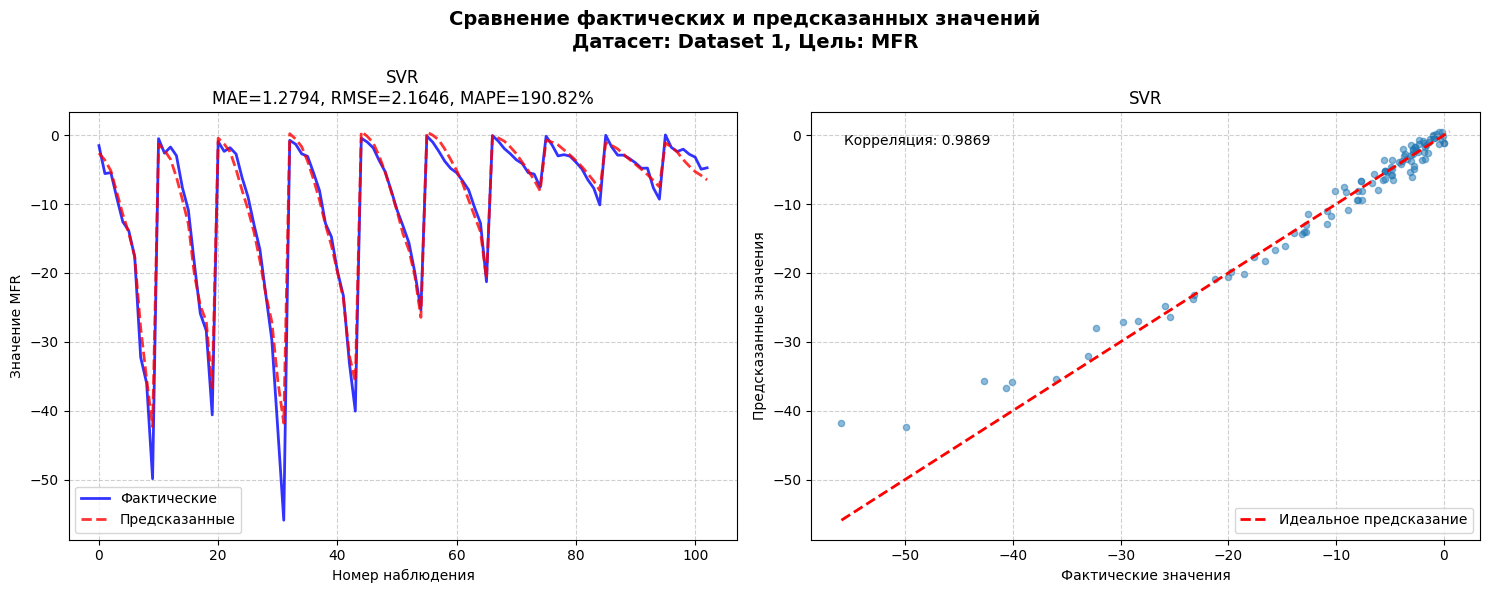

In [61]:
# Пример использования:
plot_predictions(
    model=model_SVR_DS1_MFR,
    X_test=X_test_df1_scaled,
    y_true=y_test_df1_MFR.ravel(),  # фактические значения
    y_scaler=y_scaler_ds1_MFR,
    target_name='MFR',
    dataset_name='Dataset 1',
    plot_type='both'
)

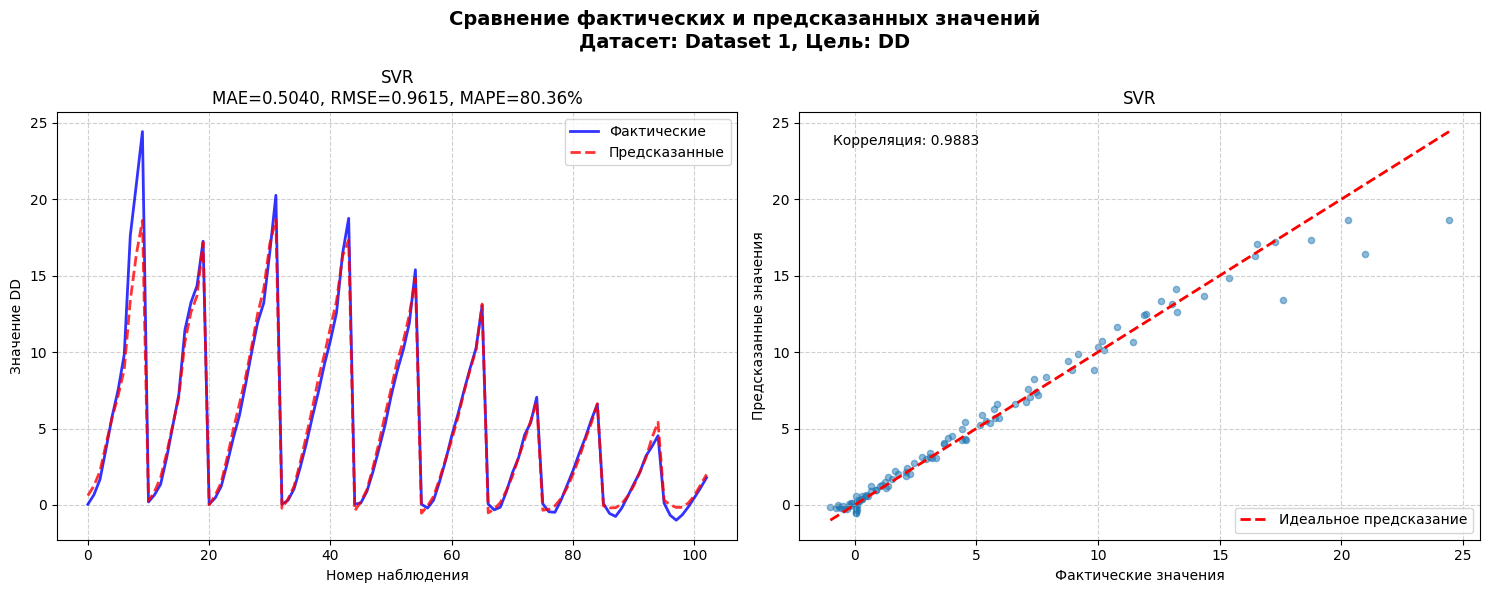

In [62]:
# Пример использования:
plot_predictions(
    model=model_SVR_DS1_DD,
    X_test=X_test_df1_scaled,
    y_true=y_test_df1_DD.ravel(),  # фактические значения
    y_scaler=y_scaler_ds1_DD,
    target_name='DD',
    dataset_name='Dataset 1',
    plot_type='both'
)

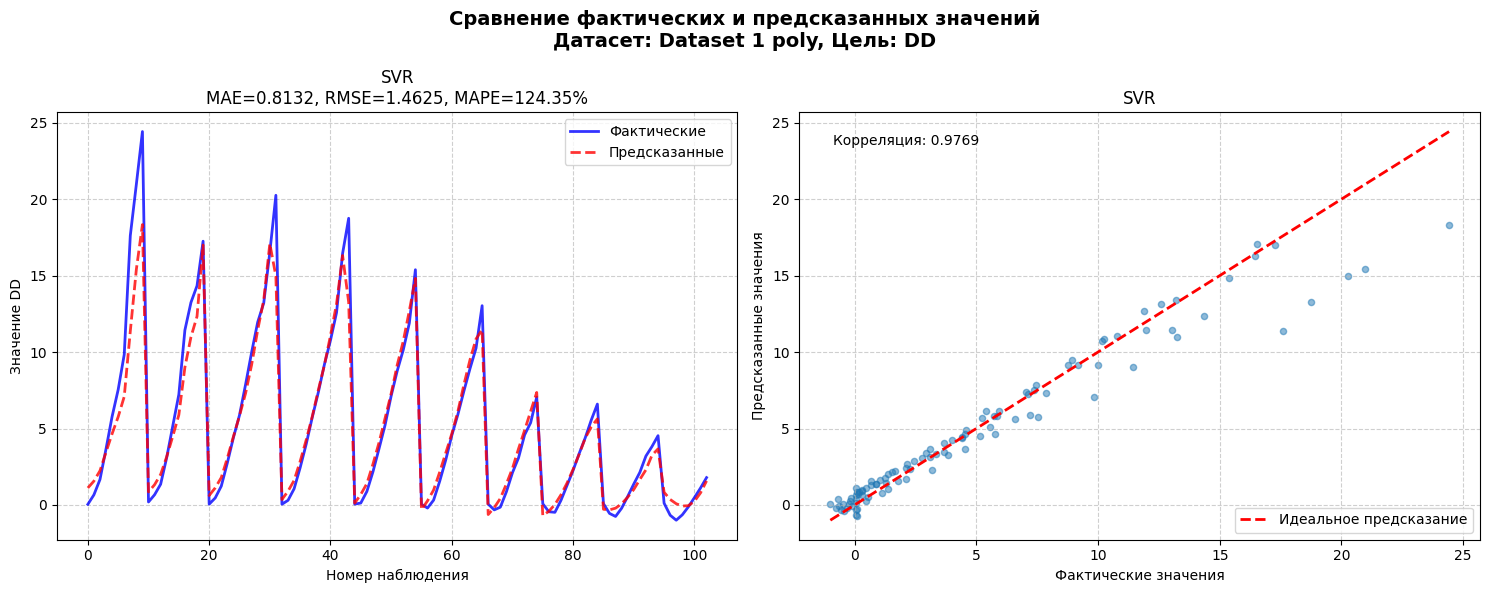

In [63]:
plot_predictions(
    model=model_SVR_DS1_DD_poly,
    X_test=X_test_poly_scaled,
    y_true=y_test_poly_DD.ravel(),  # фактические значения
    y_scaler=y_scaler_poly_DD,
    target_name='DD',
    dataset_name='Dataset 1 poly',
    plot_type='both'
)

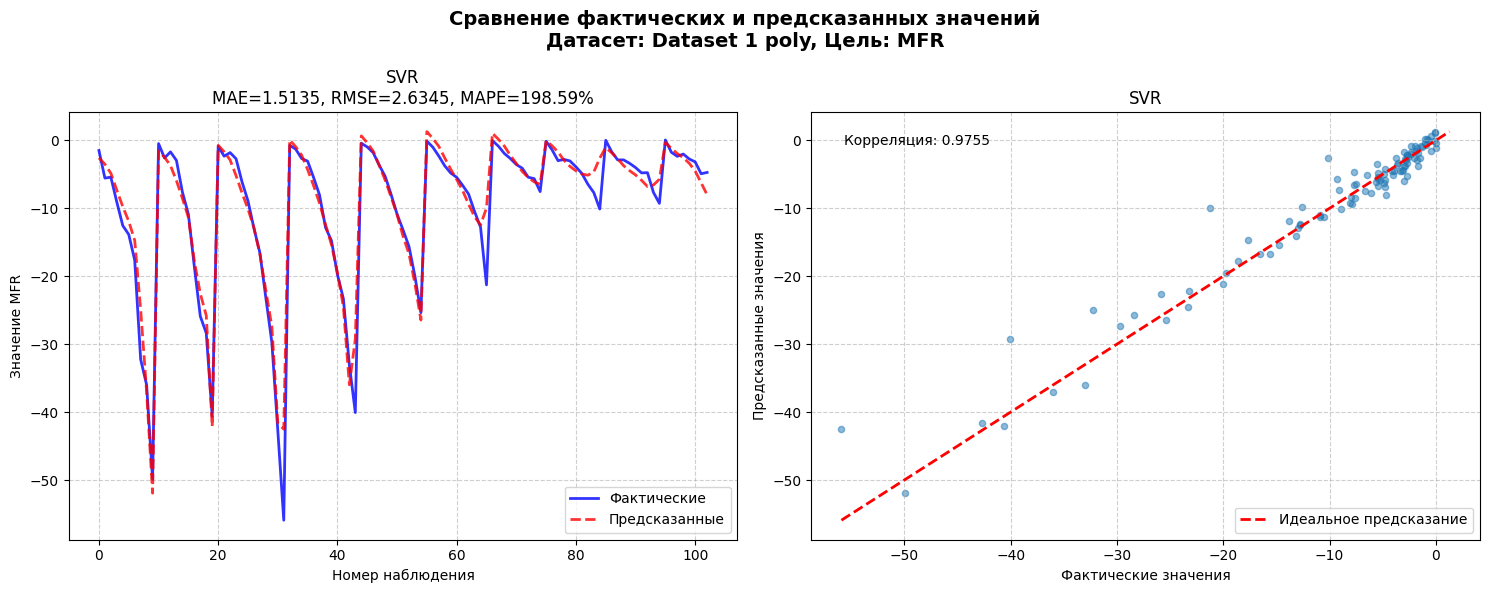

In [68]:
plot_predictions(
    model=model_SVR_DS1_MFR_poly,
    X_test=X_test_poly_scaled,
    y_true=y_test_poly_MFR.ravel(),  # фактические значения
    y_scaler=y_scaler_poly_MFR,
    target_name='MFR',
    dataset_name='Dataset 1 poly',
    plot_type='both'
)

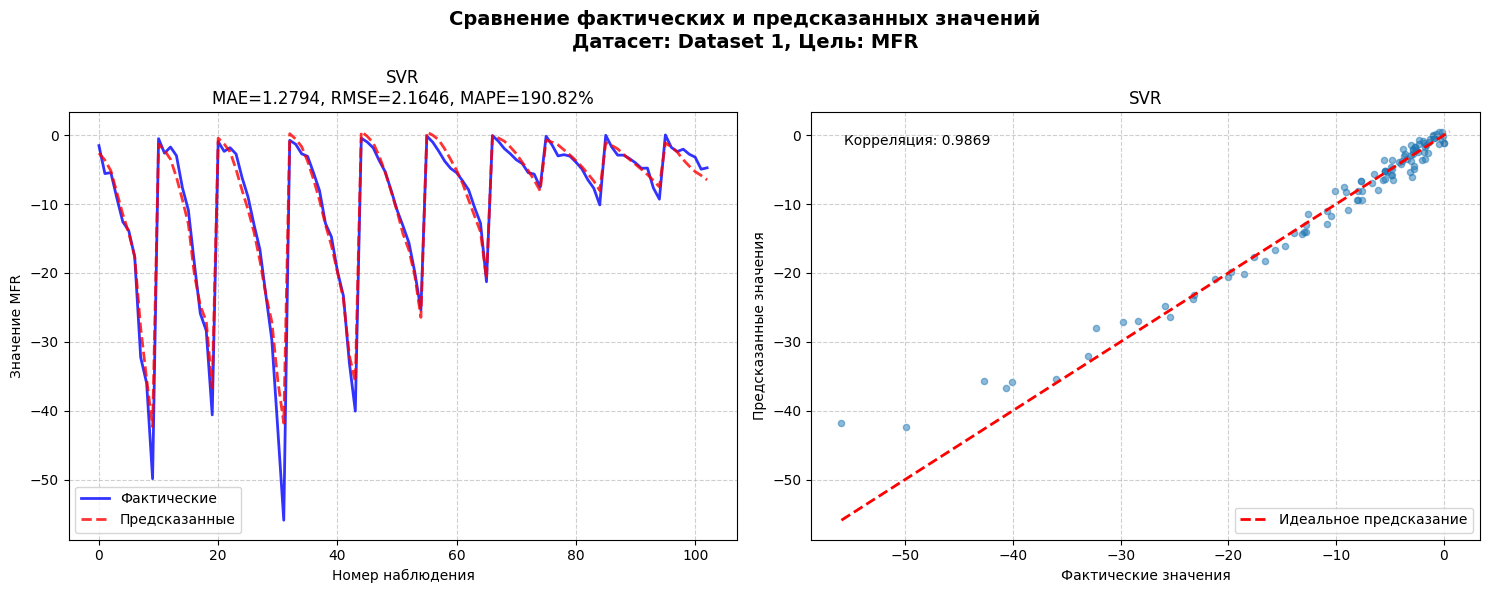

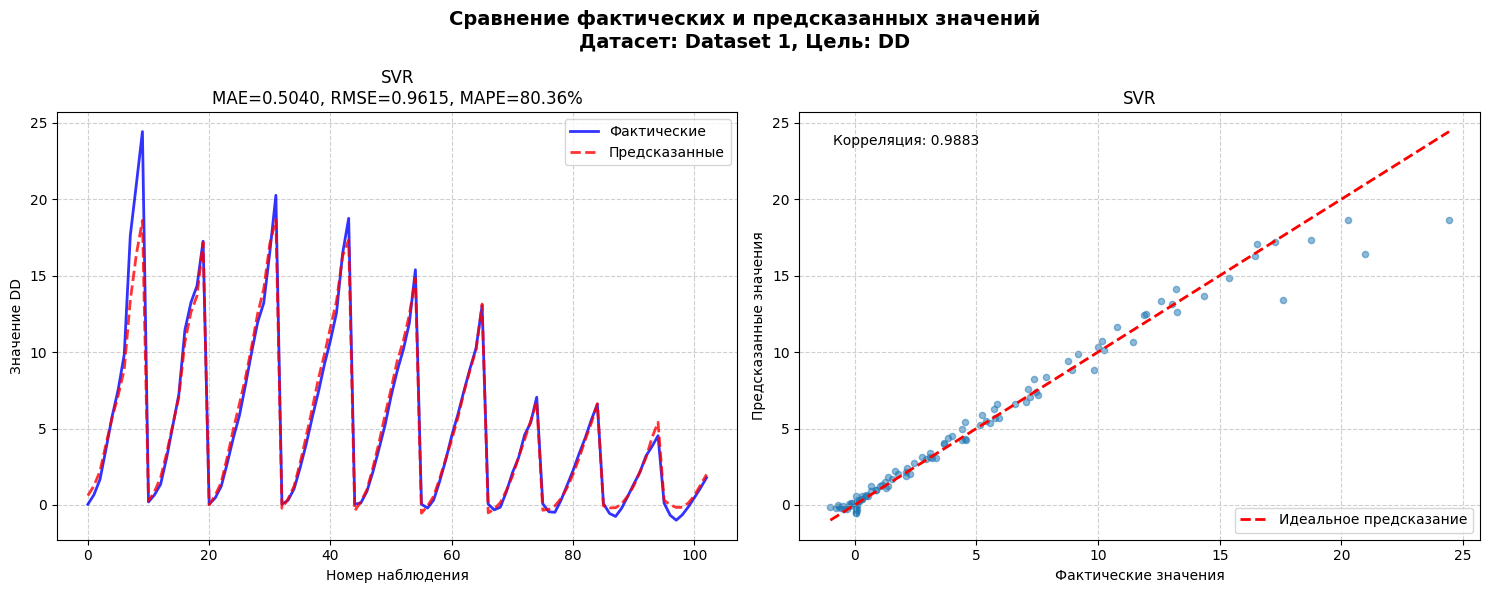

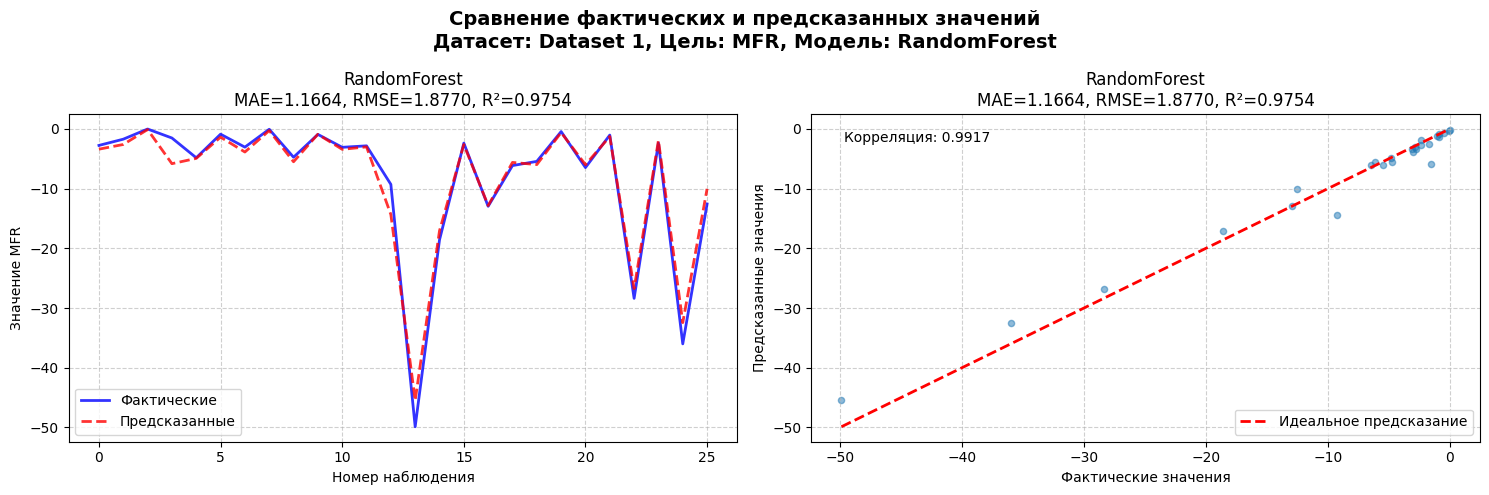

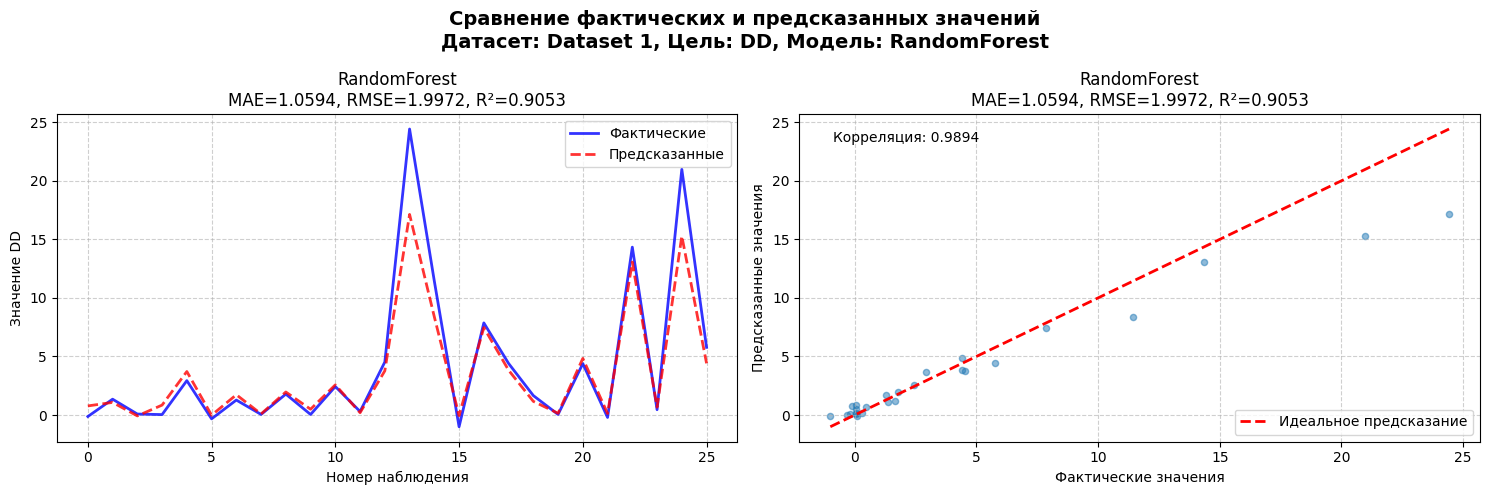

In [65]:
# @title
# ========== Построение графиков с использованием сохраненных метрик ==========

# Пример использования:
plot_predictions(
    model=model_SVR_DS1_MFR,
    X_test=X_test_df1_scaled,
    y_true=y_test_df1_MFR.ravel(),  # фактические значения
    y_scaler=y_scaler_ds1_MFR,
    target_name='MFR',
    dataset_name='Dataset 1',
    plot_type='both'
)

# Пример использования:
plot_predictions(
    model=model_SVR_DS1_DD,
    X_test=X_test_df1_scaled,
    y_true=y_test_df1_DD.ravel(),  # фактические значения
    y_scaler=y_scaler_ds1_DD,
    target_name='DD',
    dataset_name='Dataset 1',
    plot_type='both'
)

# Для RandomForest на MFR
if 'RF' in tree_models['dataset1']['MFR']:
    plot_tree_predictions(
        tree_models['dataset1']['MFR']['RF'],
        target_name='MFR',
        dataset_name='Dataset 1',
        plot_type='both'
    )

# Для RandomForest на DD
if 'RF' in tree_models['dataset1']['DD']:
    plot_tree_predictions(
        tree_models['dataset1']['DD']['RF'],
        target_name='DD',
        dataset_name='Dataset 1',
        plot_type='both'
    )

In [66]:
!pip install openpyxl

In [67]:
import pandas as pd
import numpy as np
from openpyxl import load_workbook
from openpyxl.styles import Font, PatternFill, Alignment

# Функция для форматирования параметров в строку
def format_params(params_dict):
    if not params_dict:
        return "-"
    params_str = ", ".join([f"{k}={v}" for k, v in params_dict.items()])
    return params_str

# Функция для преобразования словаря в DataFrame
def experiments_to_dataframe(experiments_dict):
    rows = []

    for model_name, datasets in experiments_dict.items():
        for dataset_name, methods in datasets.items():
            for method_name, metrics in methods.items():
                row = {
                    'Model': model_name,
                    'Dataset': dataset_name,
                    'Method': method_name,
                    'MAE': metrics.get('MAE'),
                    'RMSE': metrics.get('RMSE'),
                    'MSE': metrics.get('MSE'),
                    'MAPE': metrics.get('MAPE'),
                    'R2': metrics.get('R2'),
                    'Overfit_Ratio': metrics.get('Overfit_Ratio'),
                    'CV_Stability': metrics.get('CV_Stability'),
                    'CV_Mean_Score': metrics.get('CV_Mean_Score'),
                    'CV_Std_Score': metrics.get('CV_Std_Score'),
                    'Sensitivity_noise_1%': metrics.get('Sensitivity', {}).get('noise_1%'),
                    'Sensitivity_noise_5%': metrics.get('Sensitivity', {}).get('noise_5%'),
                    'Sensitivity_noise_10%': metrics.get('Sensitivity', {}).get('noise_10%'),
                    'Time (seconds)': metrics.get('Time'),
                    'Parameters': format_params(metrics.get('Params', {}))
                }

                rows.append(row)

    return pd.DataFrame(rows)

# Создаем основной DataFrame
df_main = experiments_to_dataframe(experiments)

# Сохраняем в Excel с несколькими листами
output_file = 'experiments_results.xlsx'

with pd.ExcelWriter(output_file, engine='openpyxl') as writer:
    # Лист 1: Все данные
    df_main.to_excel(writer, sheet_name='All_Experiments', index=False)

# Форматирование Excel файла
wb = load_workbook(output_file)
for sheet_name in wb.sheetnames:
    ws = wb[sheet_name]

    # Настройка заголовков
    header_font = Font(bold=True, color="FFFFFF")
    header_fill = PatternFill(start_color="366092", end_color="366092", fill_type="solid")
    header_alignment = Alignment(horizontal="center", vertical="center")

    # Применяем стили к первой строке (заголовки)
    if ws.max_row > 0:
        for cell in ws[1]:
            cell.font = header_font
            cell.fill = header_fill
            cell.alignment = header_alignment

    # Автоматическая ширина столбцов
    for column in ws.columns:
        max_length = 0
        column_letter = column[0].column_letter
        for cell in column:
            try:
                if len(str(cell.value)) > max_length:
                    max_length = len(str(cell.value))
            except:
                pass
        adjusted_width = min(max_length + 2, 35)
        ws.column_dimensions[column_letter].width = adjusted_width

wb.save(output_file)

# ИИ